In [ ]:
from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression;

In [ ]:
uploaded = files.upload()
data = pd.read_csv("python project.csv")

Saving python project.csv to python project.csv


In [ ]:
print(data['DATE'])

0      01-01-2024
1      02-01-2024
2      03-01-2024
3      04-01-2024
4      05-01-2024
          ...    
618    10-09-2025
619    11-09-2025
620    12-09-2025
621    13-09-2025
622    14-09-2025
Name: DATE, Length: 623, dtype: object


In [ ]:
data.head()

,DATE,DAM-VOL(IEX),AVG. DAM PRICE(IEX),MIN DAM PRICE(IEX),MAX DAM PRICE(IEX),RTM-VOL(IEX),AVG. RTM PRICE(IEX),MIN RTM PRICE(IEX),MAX RTM PRICE(IEX)
0,01-01-2024,177.61,5.22,2.34,10.0,73.95,4.61,1.71,10.0
1,02-01-2024,165.87,5.58,2.45,10.0,76.57,5.10,1.85,10.0
2,03-01-2024,158.15,5.08,1.87,10.0,76.44,6.07,2.34,10.0
3,04-01-2024,175.98,5.57,2.00,10.0,69.15,6.38,1.87,10.0
4,05-01-2024,180.63,5.69,2.00,10.0,77.31,6.45,1.85,10.0


In [ ]:
data['DATE'] = pd.to_datetime(data['DATE'], errors = 'coerce')

In [ ]:
print(data.head())

        DATE  DAM-VOL(IEX)  AVG. DAM PRICE(IEX)  MIN DAM PRICE(IEX)  \
0 2024-01-01        177.61                 5.22                2.34   
1 2024-02-01        165.87                 5.58                2.45   
2 2024-03-01        158.15                 5.08                1.87   
3 2024-04-01        175.98                 5.57                2.00   
4 2024-05-01        180.63                 5.69                2.00   

   MAX DAM PRICE(IEX)  RTM-VOL(IEX)  AVG. RTM PRICE(IEX)  MIN RTM PRICE(IEX)  \
0                10.0         73.95                 4.61                1.71   
1                10.0         76.57                 5.10                1.85   
2                10.0         76.44                 6.07                2.34   
3                10.0         69.15                 6.38                1.87   
4                10.0         77.31                 6.45                1.85   

   MAX RTM PRICE(IEX)  
0                10.0  
1                10.0  
2                10.

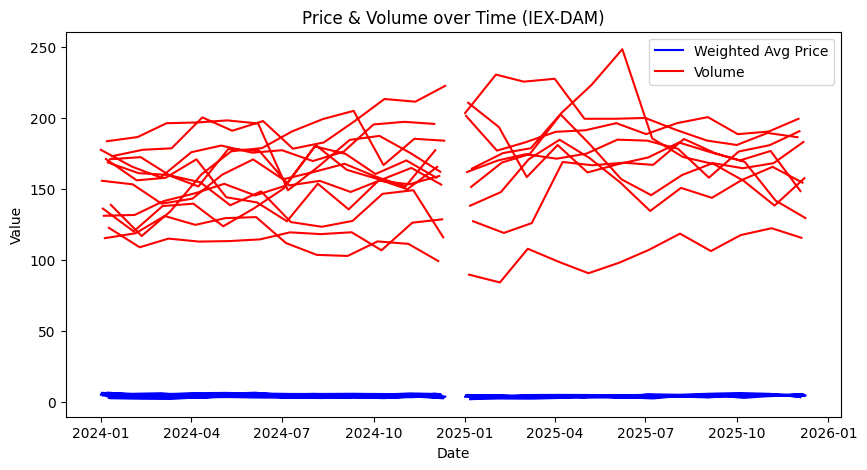

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(data["DATE"], data["AVG. DAM PRICE(IEX)"], label="Weighted Avg Price", color="blue")
plt.plot(data["DATE"], data["DAM-VOL(IEX)"], label="Volume", color="red")
plt.xlabel("Date")
plt.ylabel("Value")
plt.title("Price & Volume over Time (IEX-DAM)")
plt.legend()
plt.show()

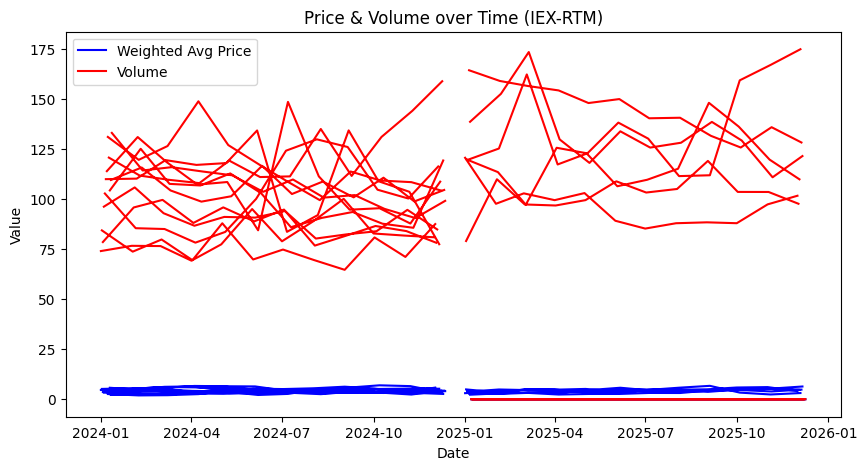

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(data["DATE"], data["AVG. RTM PRICE(IEX)"], label="Weighted Avg Price", color="blue")
plt.plot(data["DATE"], data["RTM-VOL(IEX)"], label="Volume", color="red")
plt.xlabel("Date")
plt.ylabel("Value")
plt.title("Price & Volume over Time (IEX-RTM)")
plt.legend()
plt.show()

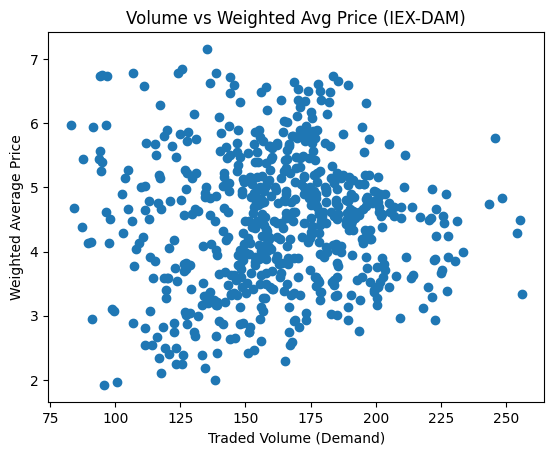

In [ ]:
plt.scatter(data["DAM-VOL(IEX)"], data["AVG. DAM PRICE(IEX)"])
plt.xlabel("Traded Volume (Demand)")
plt.ylabel("Weighted Average Price")
plt.title("Volume vs Weighted Avg Price (IEX-DAM)")
plt.show()

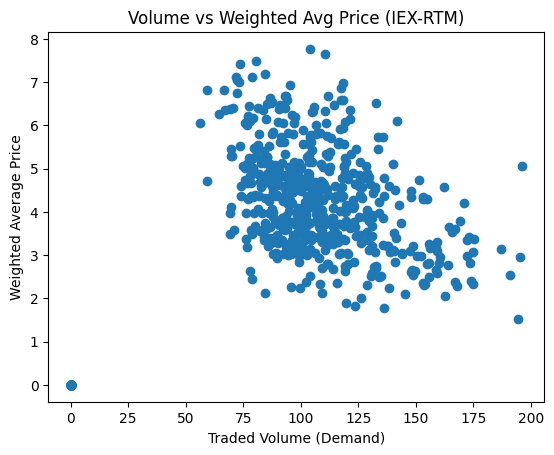

In [ ]:
plt.scatter(data["RTM-VOL(IEX)"], data["AVG. RTM PRICE(IEX)"])
plt.xlabel("Traded Volume (Demand)")
plt.ylabel("Weighted Average Price")
plt.title("Volume vs Weighted Avg Price (IEX-RTM)")
plt.show()

In [ ]:
X_DAM = data[['AVG. DAM PRICE(IEX)']]
y_DAM = data['DAM-VOL(IEX)']
X_DAM = sm.add_constant(X_DAM)

In [ ]:
model_DAM = sm.OLS(y_DAM, X_DAM).fit()
print("\nRegression Summary (IEX-DAM):")
print(model_DAM.summary())


Regression Summary (IEX-DAM):
                            OLS Regression Results                            
Dep. Variable:           DAM-VOL(IEX)   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.6952
Date:                Thu, 06 Aug 2026   Prob (F-statistic):              0.405
Time:                        19:27:11   Log-Likelihood:                -3035.1
No. Observations:                 623   AIC:                             6074.
Df Residuals:                     621   BIC:                             6083.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
con

In [ ]:
beta_1 = model_DAM.params["AVG. DAM PRICE(IEX)"]
print(f"\nSensitivity of Price to Volume (Beta_1): {beta_1:.4f}")


Sensitivity of Price to Volume (Beta_1): 1.0214


In [ ]:
X_RTM = data[['AVG. RTM PRICE(IEX)']]
y_RTM = data['RTM-VOL(IEX)']
X_RTM = sm.add_constant(X_RTM)

In [ ]:
model_RTM = sm.OLS(y_RTM, X_RTM).fit()
print("\nRegression Summary (IEX-RTM):")
print(model_RTM.summary())


Regression Summary (IEX-RTM):
                            OLS Regression Results                            
Dep. Variable:           RTM-VOL(IEX)   R-squared:                       0.261
Model:                            OLS   Adj. R-squared:                  0.260
Method:                 Least Squares   F-statistic:                     219.2
Date:                Thu, 06 Aug 2026   Prob (F-statistic):           1.07e-42
Time:                        19:27:20   Log-Likelihood:                -3127.4
No. Observations:                 623   AIC:                             6259.
Df Residuals:                     621   BIC:                             6268.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
con

In [ ]:
beta_1 = model_DAM.params["AVG. DAM PRICE(IEX)"]
beta_2 = model_RTM.params["AVG. RTM PRICE(IEX)"]
print(f"\nSensitivity of Price to Volume (Beta_1): {beta_1:.4f}")
print(f"\nSensitivity of Price to Volume (Beta_2): {beta_2:.4f}")


Sensitivity of Price to Volume (Beta_1): 1.0214

Sensitivity of Price to Volume (Beta_2): 12.1412


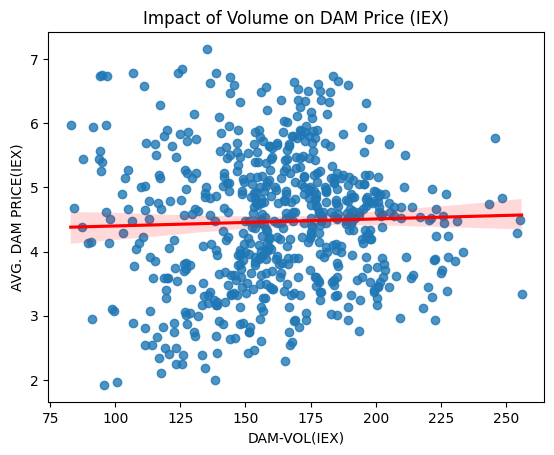

In [ ]:
sns.regplot(x='DAM-VOL(IEX)', y='AVG. DAM PRICE(IEX)', data= data, line_kws={"color":"red"})
plt.title("Impact of Volume on DAM Price (IEX)")
plt.show()

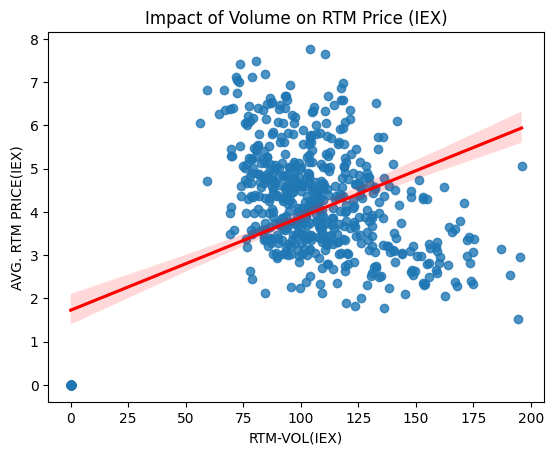

In [ ]:
sns.regplot(x='RTM-VOL(IEX)', y='AVG. RTM PRICE(IEX)', data= data, line_kws={"color":"red"})
plt.title("Impact of Volume on RTM Price (IEX)")
plt.show()